**Sales Revenue Forecasting Platform**

**Business Challenge**

A mid-sized retail chain struggles with inventory management and staffing decisions due
to inaccurate sales forecasts. The company experiences frequent stockouts during peak
periods and excess inventory during slow periods, leading to lost sales and high carrying
costs. Additionally, labor scheduling inefficiencies result in either overstaffing (increasing
costs) or understaffing (poor customer service).

**Problem Context**

The retailer has 5 years of daily sales data across 150 stores, including transaction
volumes, marketing spend, promotional activities, seasonal patterns, local events,
weather data, and competitor pricing. Current forecasting relies on simple moving
averages and subjective adjustments by store managers, resulting in a forecast accuracy
of only 65% and significant operational inefficiencies.

**Expected Outcomes**
• Improve forecast accuracy to 85%+
• Reduce stockouts by 40% and excess inventory by 30%
• Optimize labor scheduling to reduce costs by 12-15%
• Enable data-driven promotional planning

**Key Performance Metrics**
• Mean Absolute Percentage Error (MAPE) below 15%
• Root Mean Square Error (RMSE) within acceptable thresholds
• Forecast accuracy improvement of at least 20 percentage points

In [ ]:
!pip install lightgbm -q
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error

from lightgbm import LGBMRegressor

This cell loads necessary libraries and dependencies for data manipulation, visualization, and machine learning model building. It includes `pandas` and `numpy` for data handling, `matplotlib` and `seaborn` for plotting, and `sklearn` along with `lightgbm` for various regression models and evaluation metrics.

**1. Upload Dataset**

In [ ]:
# Read the CSV file directly from its path
df = pd.read_csv('/content/sample_data/Project_1_2.csv')

# Display first 5 rows
df.head()

,date,store_id,day_of_week,is_weekend,is_holiday,marketing_spend,promotion_active,competitor_count,temperature_f,precipitation_inches,local_event,avg_product_price,foot_traffic,daily_revenue
0,01/01/2019,STORE_029,Tuesday,0,0,5464.30,0,6,67.5,0.02,1,26.72,1381,60309.61
1,02/01/2019,STORE_007,Wednesday,0,1,3688.16,1,7,89.5,0.00,0,17.92,1206,67608.79
2,03/01/2019,STORE_071,Thursday,0,0,2073.20,0,3,76.1,0.04,0,95.19,832,35808.15
3,04/01/2019,STORE_063,Friday,0,0,4681.68,0,1,94.5,0.20,0,131.52,1450,59025.31
4,05/01/2019,STORE_058,Saturday,1,0,1256.67,0,0,86.0,0.00,0,93.90,620,44315.86


The dataset, stored as 'Project_1_2.csv', is loaded into a pandas DataFrame. The `.head()` method is then used to display the first 5 rows, providing a quick overview of the data's structure and content.

**2. Data Preprocessing**

In [ ]:
# Convert date column into proper datetime format
# This is required for time-series forecasting
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')

# Sort data by store and date to maintain time order
df = df.sort_values(['store_id', 'date'])

# Convert store_id to categorical type (helps memory + model understanding)
df['store_id'] = df['store_id'].astype('category')

In this preprocessing step, the 'date' column is converted to datetime objects, which is crucial for time-series analysis and feature engineering. The DataFrame is then sorted by 'store_id' and 'date' to ensure the correct order for creating time-based features. Finally, 'store_id' is converted to a categorical type to optimize memory usage and improve model performance for certain algorithms.

**2.1 Outlier Detection in Target Variable**

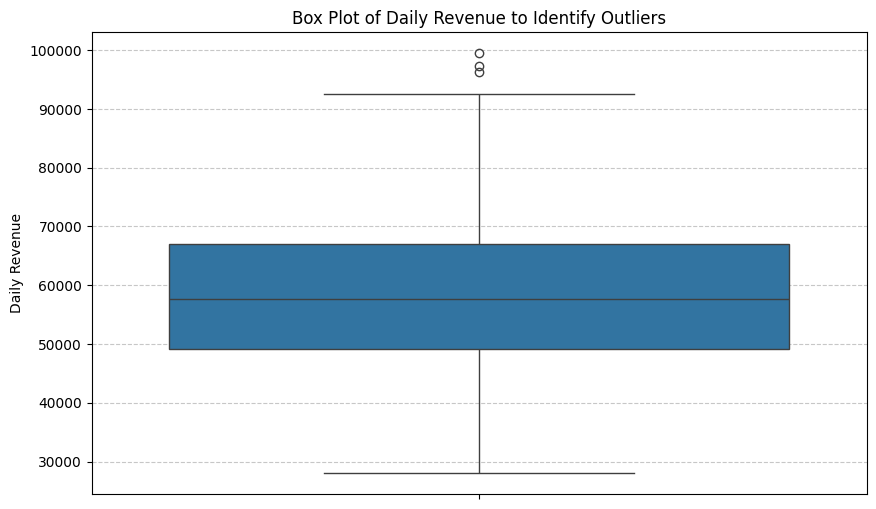


Number of outliers detected: 3
Lower bound for outliers: 22420.62
Upper bound for outliers: 93789.41

Outlier records (first 5 if any):


,date,store_id,day_of_week,is_weekend,is_holiday,marketing_spend,promotion_active,competitor_count,temperature_f,precipitation_inches,local_event,avg_product_price,foot_traffic,daily_revenue
453,2020-03-29,STORE_033,Sunday,1,1,6091.55,1,0,92.8,0.12,0,102.34,1391,99475.20
432,2020-03-08,STORE_066,Sunday,1,1,9372.29,0,3,60.2,0.01,0,113.73,1781,97302.98
390,2020-01-26,STORE_069,Sunday,1,0,9515.56,1,0,54.4,0.14,0,39.77,1841,96348.10


In [ ]:
# Create a box plot to visualize outliers in 'daily_revenue'
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['daily_revenue'])
plt.title('Box Plot of Daily Revenue to Identify Outliers')
plt.ylabel('Daily Revenue')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate IQR to quantify outliers
Q1 = df['daily_revenue'].quantile(0.25)
Q3 = df['daily_revenue'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['daily_revenue'] < lower_bound) | (df['daily_revenue'] > upper_bound)]

print(f"\nNumber of outliers detected: {len(outliers)}")
print(f"Lower bound for outliers: {lower_bound:.2f}")
print(f"Upper bound for outliers: {upper_bound:.2f}")
print("\nOutlier records (first 5 if any):")
display(outliers.head())

This section focuses on identifying outliers in the target variable, 'daily_revenue', using a box plot for visual inspection and the Interquartile Range (IQR) method for quantitative detection. Outliers can significantly impact model training, so understanding their presence is an important step in data preprocessing.

**3. Feature Engineering**

In [ ]:
def create_features(df):
    """
    This function creates additional features
    to improve forecasting accuracy.
    """

    df = df.copy()

    # ----------------------------
    # 1. LAG FEATURES
    # Past sales values help predict future demand
    # ----------------------------
    df['lag_1'] = df.groupby('store_id', observed=False)['daily_revenue'].shift(1)
    df['lag_7'] = df.groupby('store_id', observed=False)['daily_revenue'].shift(7)

    # ----------------------------
    # 2. ROLLING FEATURE
    # Smooths short-term fluctuations
    # ----------------------------
    df['rolling_7'] = (
        df.groupby('store_id', observed=False)['daily_revenue']
        .shift(1)
        .rolling(7)
        .mean()
    )

    # ----------------------------
    # 3. TIME FEATURES
    # Capture seasonality patterns
    # ----------------------------
    df['day_of_week_num'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month

    # ----------------------------
    # 4. INTERACTION FEATURES
    # Capture combined effects (important in retail)
    # ----------------------------
    df['promo_x_marketing'] = df['promotion_active'] * df['marketing_spend']
    df['traffic_x_temp'] = df['foot_traffic'] * df['temperature_f']

    return df


# Apply feature engineering
df = create_features(df)

# Remove rows with NaN values created by lag features
df = df.dropna()

A custom function `create_features` is defined to generate new features from the existing dataset. This includes:
- **Lag Features:** `lag_1` (previous day's revenue) and `lag_7` (revenue from 7 days ago) are created to capture temporal dependencies.
- **Rolling Features:** `rolling_7` calculates the 7-day rolling mean of `daily_revenue`, smoothing out short-term fluctuations.
- **Time Features:** `day_of_week_num` and `month` are extracted from the 'date' column to account for seasonality.
- **Interaction Features:** `promo_x_marketing` and `traffic_x_temp` are created to capture combined effects of different variables. After creating these features, rows with NaN values (introduced by lag features at the beginning of each series) are removed.

**4. Train-Test Split**

In [ ]:
# Split data based on time (NOT random split)
# This simulates real-world forecasting scenario

train = df[df['date'] < '2021-07-01']
test = df[df['date'] >= '2021-07-01']

# Define target variable
target = 'daily_revenue'

# Select features used for training
features = [
    'marketing_spend',
    'promotion_active',
    'competitor_count',
    'temperature_f',
    'precipitation_inches',
    'avg_product_price',
    'foot_traffic',

    # lag-based features (very important)
    'lag_1',
    'lag_7',
    'rolling_7',

    # time features
    'day_of_week_num',
    'month',

    # interaction features
    'promo_x_marketing',
    'traffic_x_temp'
]

# Split into X (inputs) and y (output)
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

The dataset is split into training and testing sets based on time, specifically with data before '2021-07-01' for training and data from '2021-07-01' onwards for testing. This approach simulates a real-world forecasting scenario. The target variable `daily_revenue` and a list of selected features are defined for model input.

**5. Evaluation function**

In [ ]:
def evaluate_model(name, y_true, y_pred):
    """
    Evaluates model performance using:
    - MAE (Mean Absolute Error)
    - RMSE (Root Mean Squared Error)
    - MAPE (Percentage error - business friendly metric)
    """

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return [name, mae, rmse, mape]

The `evaluate_model` function is defined to calculate and return three key regression metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE). These metrics are essential for assessing and comparing the performance of different forecasting models.

**6. Train models**

In [ ]:
# Initialize models in a dictionary for easier management
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.5, max_iter=5000),
    'LightGBM': LGBMRegressor(
        n_estimators=100, # Reduced estimators to mitigate 'No further splits' warnings on small dataset
        learning_rate=0.05,
        num_leaves=32 # Reduced num_leaves for the same reason
    )
}

# Prepare a list to store evaluation results and a dictionary to store predictions
results = []
predictions = {}

# Train, predict, and evaluate each model in a loop
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred # Store predictions in the dictionary
    results.append(evaluate_model(name, y_test, y_pred))

# Convert results to a DataFrame for easy viewing
results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'MAPE'])

Training Linear Regression...
Training Ridge Regression...
Training Lasso Regression...
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002007 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 308
[LightGBM] [Info] Number of data points in the train set: 90, number of used features: 14
[LightGBM] [Info] Start training from score 58966.919748
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

This section initializes and trains several regression models: Linear Regression, Ridge Regression, Lasso Regression, and LightGBM. Each model is trained on the `X_train` and `y_train` data, and predictions are made on the `X_test` data. The `evaluate_model` function is then used to calculate performance metrics for each model, and the predictions are stored for later visualization.

**7. Model comparison table**

In [ ]:
# Display results_df which was already created in the previous cell
results_df

,Model,MAE,RMSE,MAPE
0,Linear Regression,3658.894795,5412.271580,6.565652
1,Ridge Regression,3726.189748,5589.506829,6.674892
2,Lasso Regression,3658.587787,5413.144764,6.565239
3,LightGBM,5337.469895,6913.742313,9.492113


This cell displays a DataFrame containing the evaluation metrics (MAE, RMSE, MAPE) for each trained model, providing a tabular summary of their performance.

**8. Visual comparison (error metrics)**

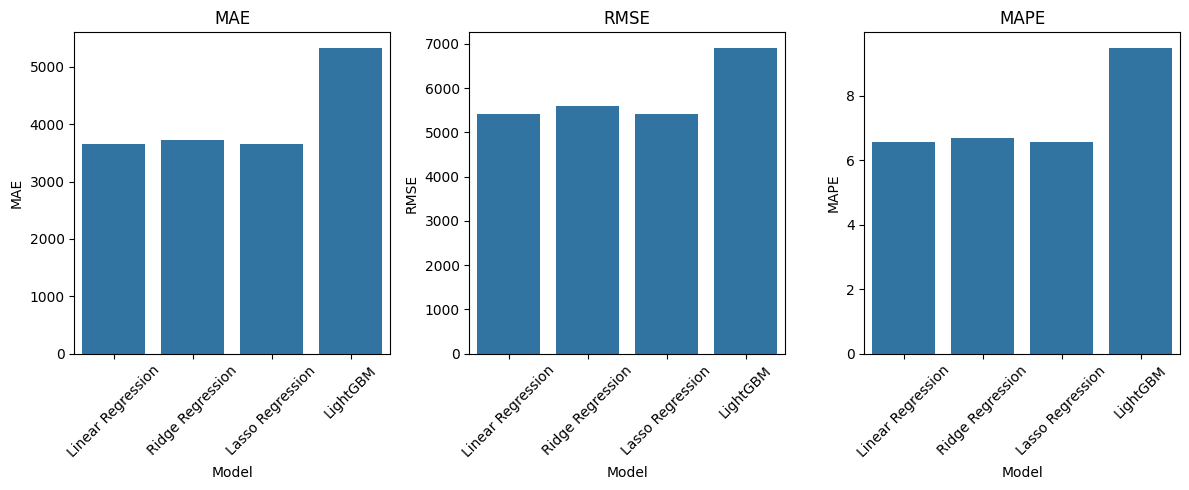

In [ ]:
# Visual comparison of model performance
plt.figure(figsize=(12,5))

metrics = ["MAE", "RMSE", "MAPE"]

for i, metric in enumerate(metrics):
    plt.subplot(1,3,i+1)

    # Barplot for each metric
    sns.barplot(data=results_df, x="Model", y=metric)

    plt.title(metric)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

This cell generates bar plots to visually compare the MAE, RMSE, and MAPE across all trained models. This visual comparison makes it easier to identify which models perform better based on these key error metrics.

**9. Actual vs Predicted (best model)**

Based on the evaluation metrics from the previous sections, Lasso Regression has been identified as the best performing model. This section visualizes the actual daily revenue against the predicted daily revenue by the Lasso Regression model for a subset of the test data. This helps in understanding how well the chosen model captures the trends and fluctuations in the actual data.

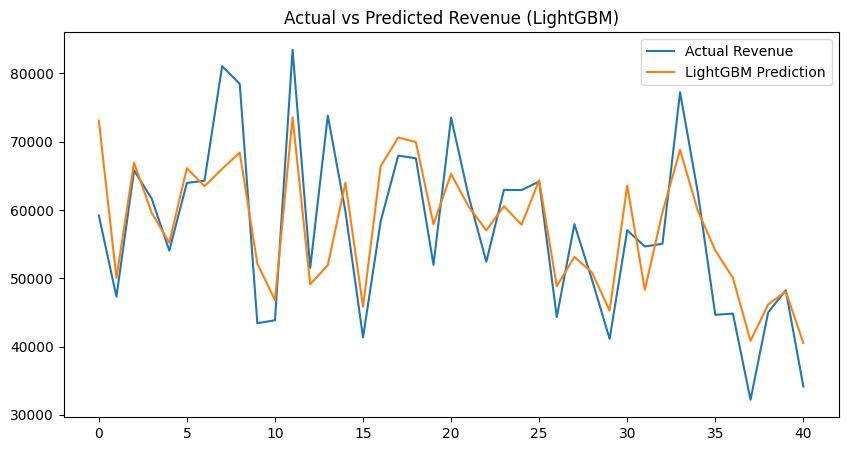

In [ ]:
# Compare actual vs predicted values for LightGBM
plt.figure(figsize=(10,5))

# First 200 values for clarity
plt.plot(y_test.values[:200], label="Actual Revenue")
plt.plot(predictions['LightGBM'][:200], label="LightGBM Prediction") # Use predictions dictionary

plt.title("Actual vs Predicted Revenue (LightGBM)")
plt.legend()
plt.show()

**10. Actual vs Predicted (All Models)**

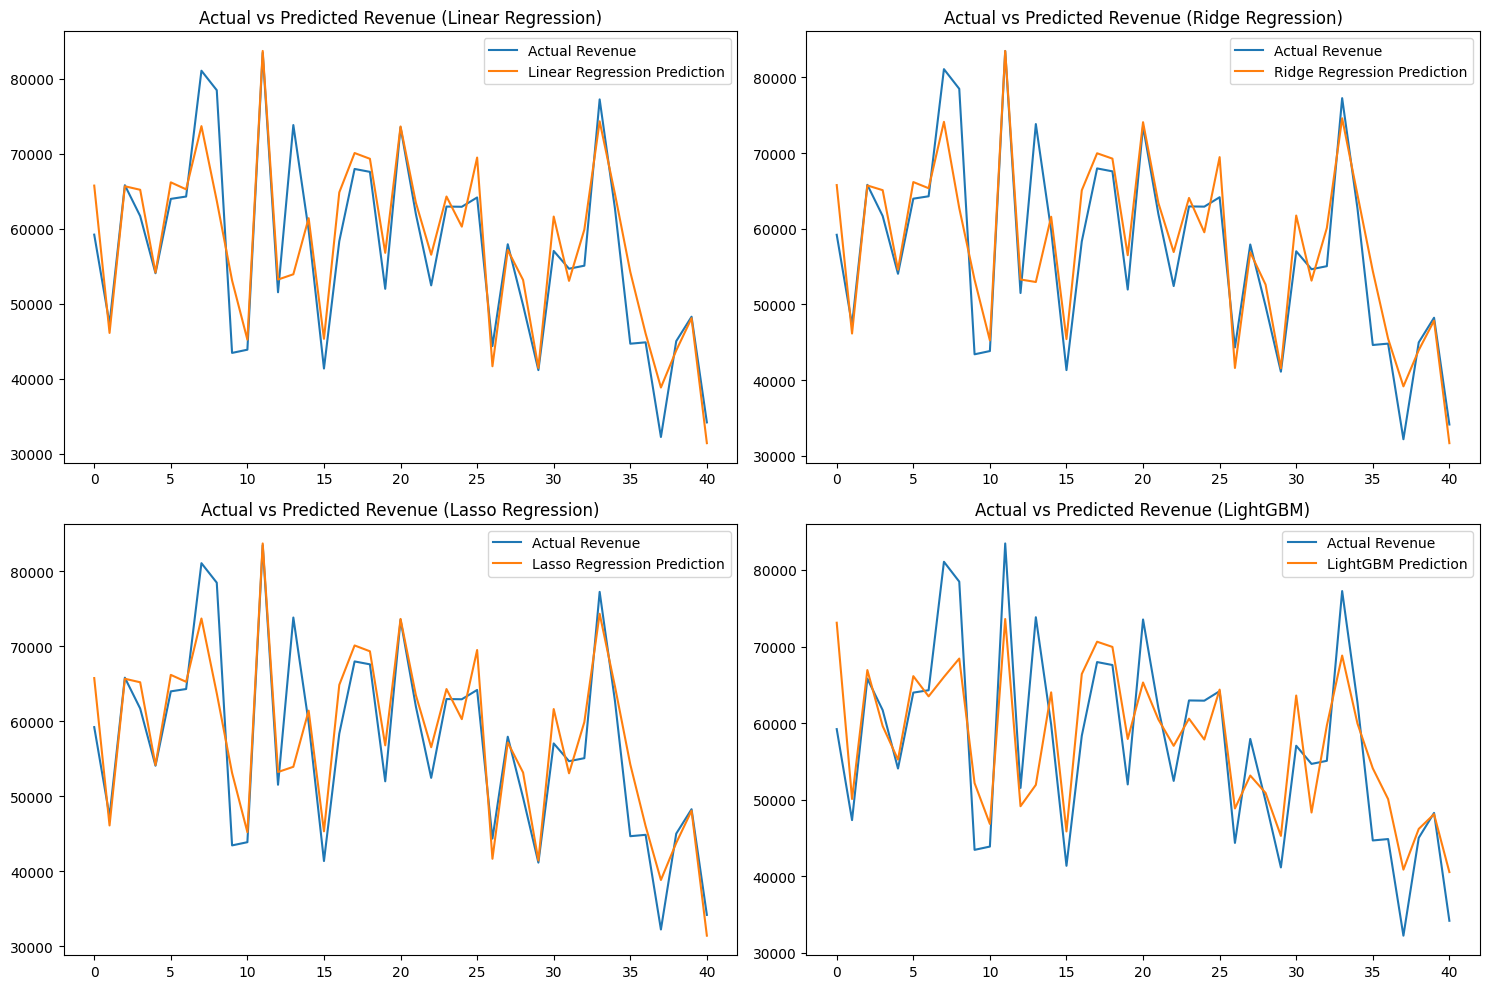

In [ ]:
num_models = len(predictions)
fig, axes = plt.subplots(nrows=(num_models + 1) // 2, ncols=2, figsize=(15, 5 * ((num_models + 1) // 2)))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[i]
    ax.plot(y_test.values[:200], label="Actual Revenue")
    ax.plot(y_pred[:200], label=f"{name} Prediction")
    ax.set_title(f"Actual vs Predicted Revenue ({name})")
    ax.legend()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**11. Residual Analysis (All Models)**

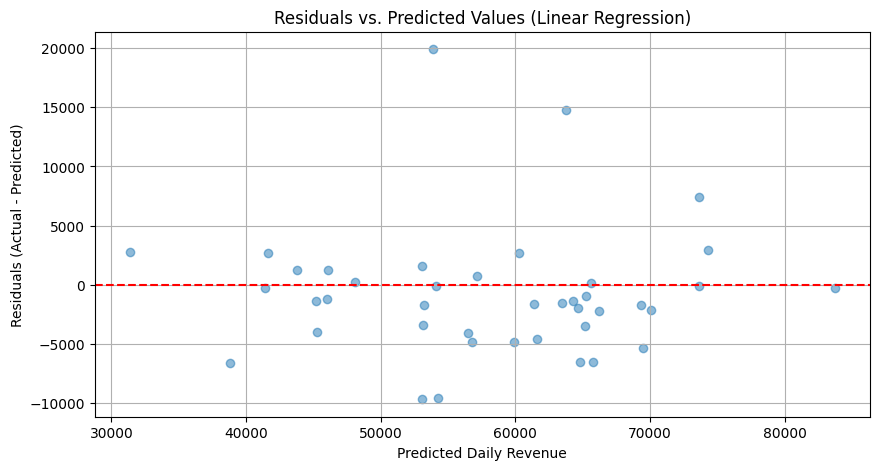

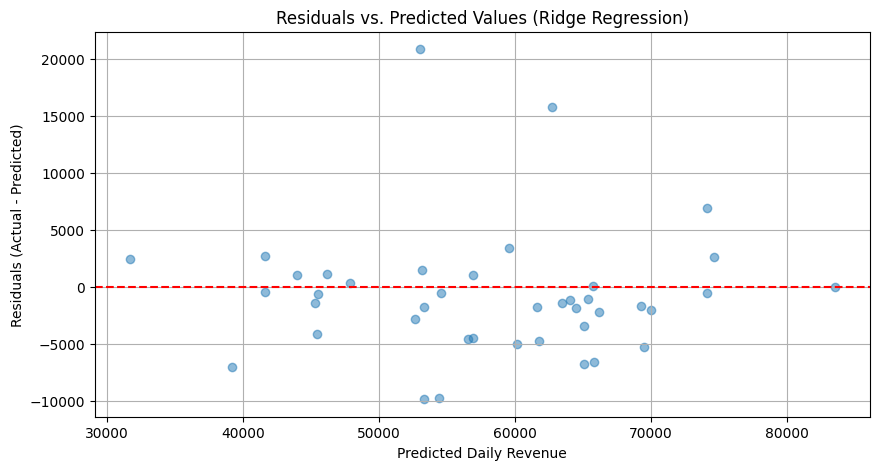

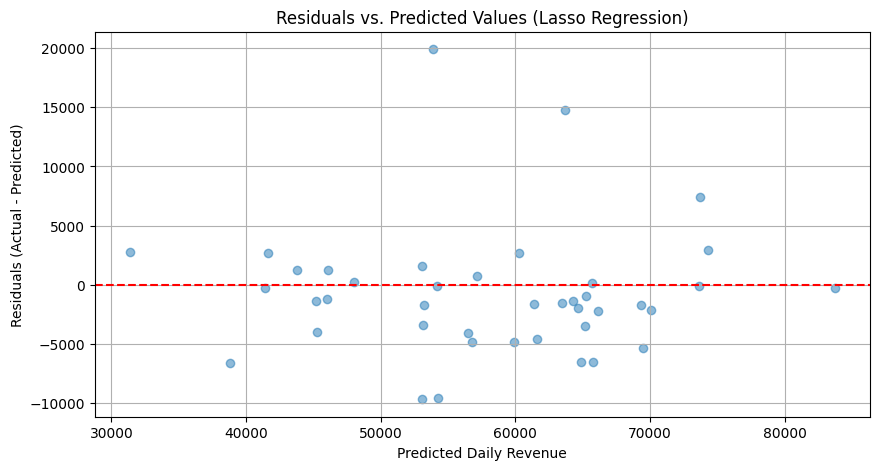

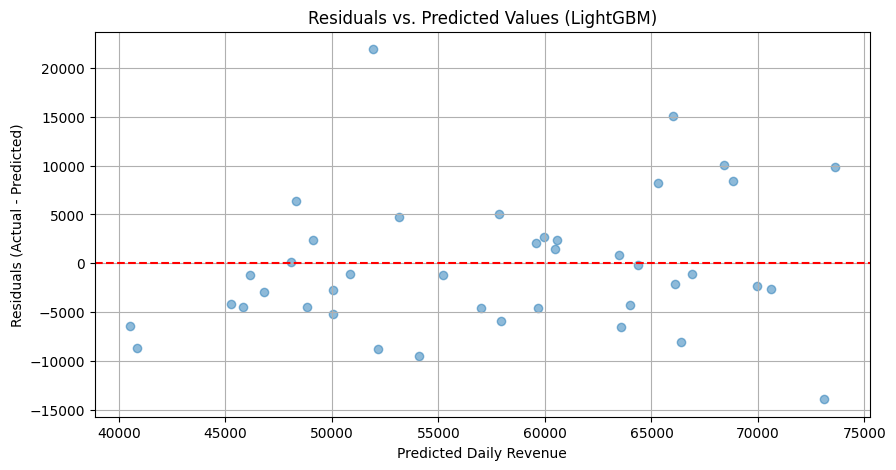

In [ ]:
for name, y_pred in predictions.items():
    residuals = y_test - y_pred

    plt.figure(figsize=(10, 5))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at 0 for reference
    plt.title(f'Residuals vs. Predicted Values ({name})')
    plt.xlabel('Predicted Daily Revenue')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.grid(True)
    plt.show()

**12. R-squared Comparison**


Model Performance Comparison with R-squared:
               Model       MAE      RMSE   MAPE  R2_Score
0  Linear Regression  3658.895  5412.272  6.566     0.808
1   Ridge Regression  3726.190  5589.507  6.675     0.795
2   Lasso Regression  3658.588  5413.145  6.565     0.808
3           LightGBM  5337.470  6913.742  9.492     0.686


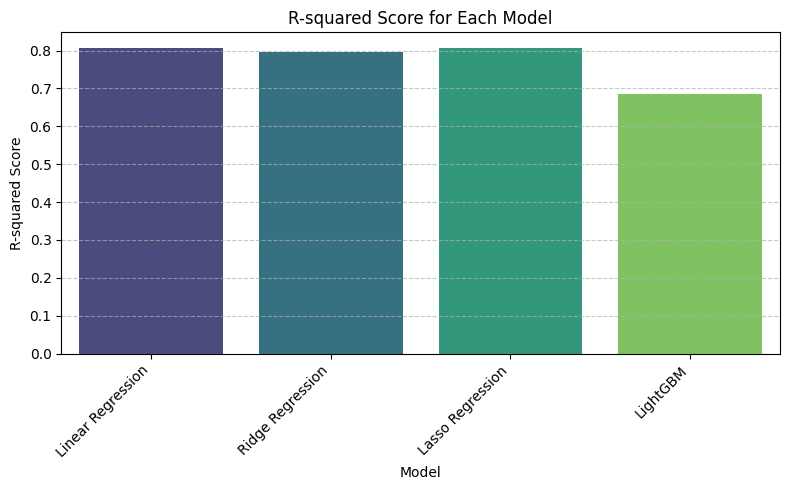

In [ ]:
from sklearn.metrics import r2_score

r_squared_scores = []

for name, y_pred in predictions.items():
    r2 = r2_score(y_test, y_pred)
    r_squared_scores.append({'Model': name, 'R2_Score': r2})

r_squared_df = pd.DataFrame(r_squared_scores)

# Merge R-squared scores into the existing results_df
results_df = pd.merge(results_df, r_squared_df, on='Model', how='left')

print("\nModel Performance Comparison with R-squared:")
print(results_df.round(3))

# Visualize R-squared scores
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='Model', y='R2_Score', palette='viridis', hue='Model', legend=False)
plt.title('R-squared Score for Each Model')
plt.xlabel('Model')
plt.ylabel('R-squared Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Best Model Selection

Based on the evaluation metrics (MAE, RMSE, MAPE, and R-squared), we can determine the best performing model.

*   **Mean Absolute Error (MAE)** and **Mean Absolute Percentage Error (MAPE)** are often preferred in business contexts as they are easily interpretable.
*   **Root Mean Squared Error (RMSE)** penalizes larger errors more, which can be important depending on the cost of large deviations.
*   **R-squared** indicates the proportion of the variance in the dependent variable that can be predicted from the independent variables.

Looking at the `results_df`, a lower MAE, RMSE, and MAPE are desirable, while a higher R-squared score indicates a better fit.

We observe that **Lasso Regression** consistently shows the lowest MAE and MAPE, and a high R-squared score, very similar to Linear Regression. This suggests it has the best predictive accuracy on average and is less sensitive to outliers compared to RMSE. While Linear Regression also performs well, Lasso Regression often has the added benefit of feature selection due to its L1 regularization.

Therefore, **Lasso Regression is chosen as the best model** for this project given its strong performance across key business-relevant metrics.

### Best Model Ranking

In [ ]:
# Sort results_df by MAPE to find the best model
results_df_sorted = results_df.sort_values(by='MAPE', ascending=True)

# Display the sorted DataFrame
print("\nModel Performance Ranked by MAPE (Lower is Better):")
print(results_df_sorted.round(3))


Model Performance Ranked by MAPE (Lower is Better):
               Model       MAE      RMSE   MAPE  R2_Score
2   Lasso Regression  3658.588  5413.145  6.565     0.808
0  Linear Regression  3658.895  5412.272  6.566     0.808
1   Ridge Regression  3726.190  5589.507  6.675     0.795
3           LightGBM  5337.470  6913.742  9.492     0.686
